In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_excel(r"C:\Users\sruja\survivor_project\archive\Voting Stats Plus.xlsx")
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [ ]:
print(df.shape)

(875, 21)


In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
print(df.columns)

Index(['id', 'playername', 'seasonplayed', 'age', 'occupation', 'hometown',
       'startingtribe', 'startingtribecolor', 'timesswapped', 'mergetribe',
       'mergetribecolor', 'finalplacement', 'votescast', 'correctlyvoted',
       'votesrecieved', 'votesnegated', 'tribeimmunities',
       'individualimmunites', 'tribalsattended', 'playersonseason',
       'advantagesplayed'],
      dtype='object')


In [ ]:
df_strategy = df[[
    "playername",
    "seasonplayed",
    "finalplacement",
    "votescast",
    "correctlyvoted",
    "votesrecieved",
    "individualimmunites",
    "tribalsattended",
    "playersonseason"
]]

In [ ]:
# Make sure all derived columns are on df_strategy first, then re-clean
df_strategy["is_winner"] = (df_strategy["finalplacement"] == 1).astype(int)
df_strategy["timesswapped"] = df["timesswapped"].values
df_strategy["made_merge"] = (df["mergetribe"] != "No Merge").astype(int)
df_strategy["negation_rate"] = (
    df["votesnegated"] / df["tribalsattended"]
).fillna(0)

# Rebuild clean dataset AFTER all columns are added
df_strategy_clean_ir = df_strategy.dropna(
    subset=["immunity_rate", "finalplacement"]
).copy()

print(f"Clean dataset: {len(df_strategy_clean_ir)} rows "
      f"({len(df_strategy) - len(df_strategy_clean_ir)} dropped)")
print(f"Winners in clean dataset: {df_strategy_clean_ir['is_winner'].sum()}")
print(f"Era counts:\n{df_strategy_clean_ir['era'].value_counts()}")

Clean dataset: 861 rows (14 dropped)
Winners in clean dataset: 48
Era counts:
era
Advantages Era (28-38)    210
Middle School (11-20)     202
Old School (1-10)         165
Dark Era (21-27)          143
New Era (41+)             141
Name: count, dtype: int64


In [ ]:
print(df_strategy.columns)

Index(['playername', 'seasonplayed', 'finalplacement', 'votescast',
       'correctlyvoted', 'votesrecieved', 'individualimmunites',
       'tribalsattended', 'playersonseason', 'is_winner', 'timesswapped',
       'made_merge', 'negation_rate'],
      dtype='object')


In [ ]:
df_strategy = df_strategy.fillna(0)

# Defining Key Variables

In [ ]:
df_strategy["correct_vote_ratio"] = (
    df_strategy["correctlyvoted"] / df_strategy["votescast"]
).fillna(0)

df_strategy["survival_score"] = (
    1 - df_strategy["finalplacement"] / df_strategy["playersonseason"]
    
)
df_strategy["target_rate"] = (
    df_strategy["votesrecieved"] / df_strategy["tribalsattended"]
    
)
df_strategy["immunity_rate"] = (
    df_strategy["individualimmunites"] / df_strategy["tribalsattended"]
)
df_strategy["immunity_rate"] = df_strategy["immunity_rate"].replace([np.inf, -np.inf], np.nan)
df_strategy_clean_ir = df_strategy.dropna(subset=["immunity_rate", "finalplacement"])

df_strategy["is_winner"] = (
    df_strategy["finalplacement"] == 1
).astype(int)

df_strategy["negation_rate"] = (
    df["votesnegated"] / df["tribalsattended"]
).fillna(0)


In [ ]:
print(df_strategy.correct_vote_ratio)

0      0.000000
1      0.000000
2      0.000000
3      0.500000
4      0.666667
         ...   
870    0.555556
871    0.777778
872    0.888889
873    0.875000
874    1.000000
Name: correct_vote_ratio, Length: 875, dtype: float64


In [ ]:
df_strategy["threat_raw"] = (
    0.35 * df_strategy["individualimmunites"] +
    0.30 * df_strategy["votesrecieved"] +
    0.20 * (df_strategy["correct_vote_ratio"] * 10) +
    0.15 * df_strategy["tribalsattended"]
)

df_strategy["threat_score"] = (
    (df_strategy["threat_raw"] - df_strategy["threat_raw"].min()) /
    (df_strategy["threat_raw"].max() - df_strategy["threat_raw"].min())
)

df_strategy["is_winner"] = (
    df_strategy["finalplacement"] == 1
).astype(int)

df_strategy.groupby("is_winner")["threat_score"].mean()

print("Average threat score:")
print(df_strategy.groupby("is_winner")["threat_score"].mean())

Average threat score:
is_winner
0    0.196295
1    0.246618
Name: threat_score, dtype: float64


# Correlation of Variables with Placement

In [ ]:
from scipy.stats import pearsonr

r, _ = pearsonr(
    df_strategy["correct_vote_ratio"],
    df_strategy["finalplacement"]
)
print("Correlation (correct_vote_ratio vs placement):", r)

r, _ = pearsonr(
    df_strategy["threat_score"],
    df_strategy["finalplacement"]
)
print("Correlation (threat_score vs placement):", r)

r, _ = pearsonr(
    df_strategy_clean_ir["immunity_rate"],
    df_strategy_clean_ir["finalplacement"]
)
print("Correlation (immunity_rate vs placement):", r)

r, _ = pearsonr(
    df_strategy_clean_ir["target_rate"],
    df_strategy_clean_ir["finalplacement"]
)

print("Correlation (target_rate vs placement):", r)

Correlation (correct_vote_ratio vs placement): -0.46114581606013644
Correlation (threat_score vs placement): -0.6231152835432946
Correlation (immunity_rate vs placement): -0.397723269379435
Correlation (target_rate vs placement): 0.688056245663871


# Data Visualization

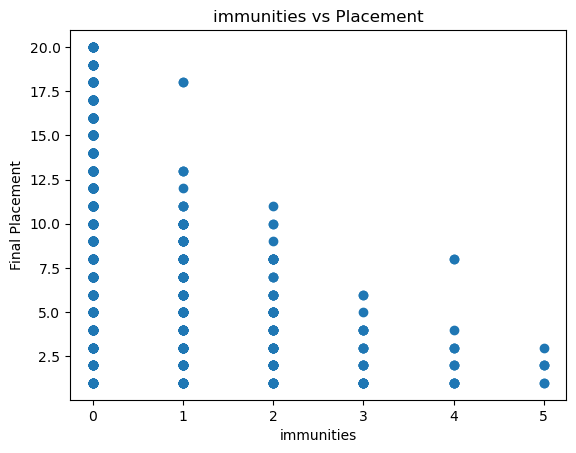

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df_strategy["individualimmunites"], df_strategy["finalplacement"])
plt.xlabel("immunities")
plt.ylabel("Final Placement")
plt.title("immunities vs Placement")
plt.show()

In [ ]:
df_strategy.groupby("is_winner")[[
    "correct_vote_ratio",
    "survival_score",
    "target_rate",
    "immunity_rate",
]].mean()

,correct_vote_ratio,survival_score,target_rate,immunity_rate
is_winner,,,,
0,0.527084,0.443759,1.899632,0.054637
1,0.838130,0.944679,0.315380,0.168795


In [ ]:
df_strategy[df_strategy["is_winner"] == 1]["correct_vote_ratio"].describe()

count    48.000000
mean      0.838130
std       0.129002
min       0.444444
25%       0.775641
50%       0.833333
75%       0.912587
max       1.000000
Name: correct_vote_ratio, dtype: float64

In [ ]:
df_strategy[df_strategy["is_winner"] == 1]["immunity_rate"].describe()

count    48.000000
mean      0.168795
std       0.144609
min       0.000000
25%       0.053571
50%       0.166667
75%       0.272727
max       0.625000
Name: immunity_rate, dtype: float64

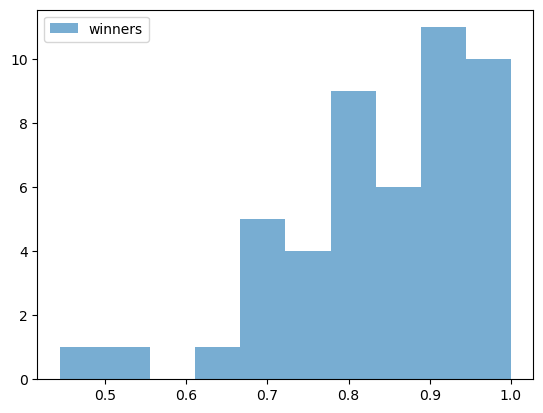

In [ ]:
plt.hist(
    df_strategy[df_strategy["is_winner"] == 1]["correct_vote_ratio"],
    alpha=0.6,
    label="winners"
)

plt.legend()
plt.show()

In [ ]:
df_strategy[[
    "correct_vote_ratio",
    "immunity_rate",
    "target_rate",
    "survival_score"
]].corrwith(df_strategy["finalplacement"])

correct_vote_ratio   -0.461146
immunity_rate        -0.397723
target_rate           0.688056
survival_score       -0.987617
dtype: float64

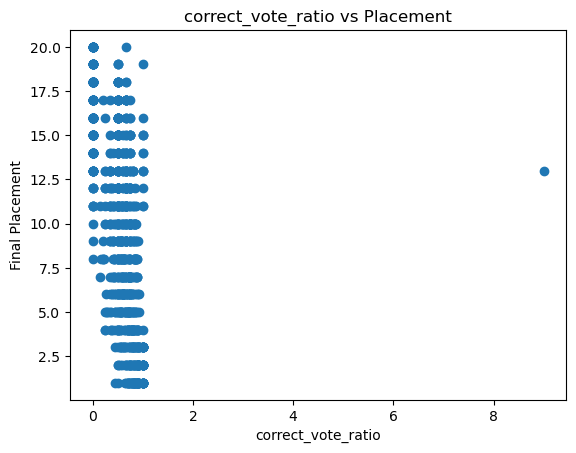

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df_strategy["correct_vote_ratio"], df_strategy["finalplacement"])
plt.xlabel("correct_vote_ratio")
plt.ylabel("Final Placement")
plt.title("correct_vote_ratio vs Placement")
plt.show()


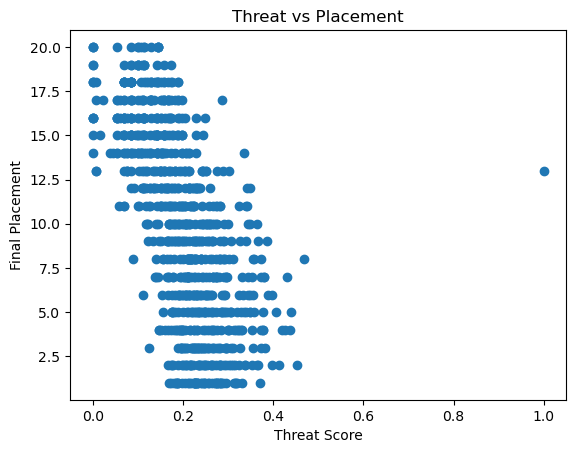

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df_strategy["threat_score"], df_strategy["finalplacement"])
plt.xlabel("Threat Score")
plt.ylabel("Final Placement")
plt.title("Threat vs Placement")
plt.show()

# Data analysis

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

features = ["correct_vote_ratio", "immunity_rate", "target_rate"]
X = df_strategy_clean_ir[features]
y = df_strategy_clean_ir["is_winner"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000)
scores = cross_val_score(lr, X_scaled, y, cv=5, scoring="roc_auc")

print("Logistic Regression — 5-fold CV ROC-AUC")
print(f"  Mean: {scores.mean():.3f}  |  Std: {scores.std():.3f}")

lr.fit(X_scaled, y)
for feat, coef in zip(features, lr.coef_[0]):
    print(f"  {feat}: {coef:.3f}")

Logistic Regression — 5-fold CV ROC-AUC
  Mean: 0.915  |  Std: 0.036
  correct_vote_ratio: 0.536
  immunity_rate: 0.462
  target_rate: -3.413


Decision Tree — 5-fold CV ROC-AUC
  Mean: 0.882  |  Std: 0.065

Feature importances:
  correct_vote_ratio: 0.100
  immunity_rate: 0.113
  target_rate: 0.787


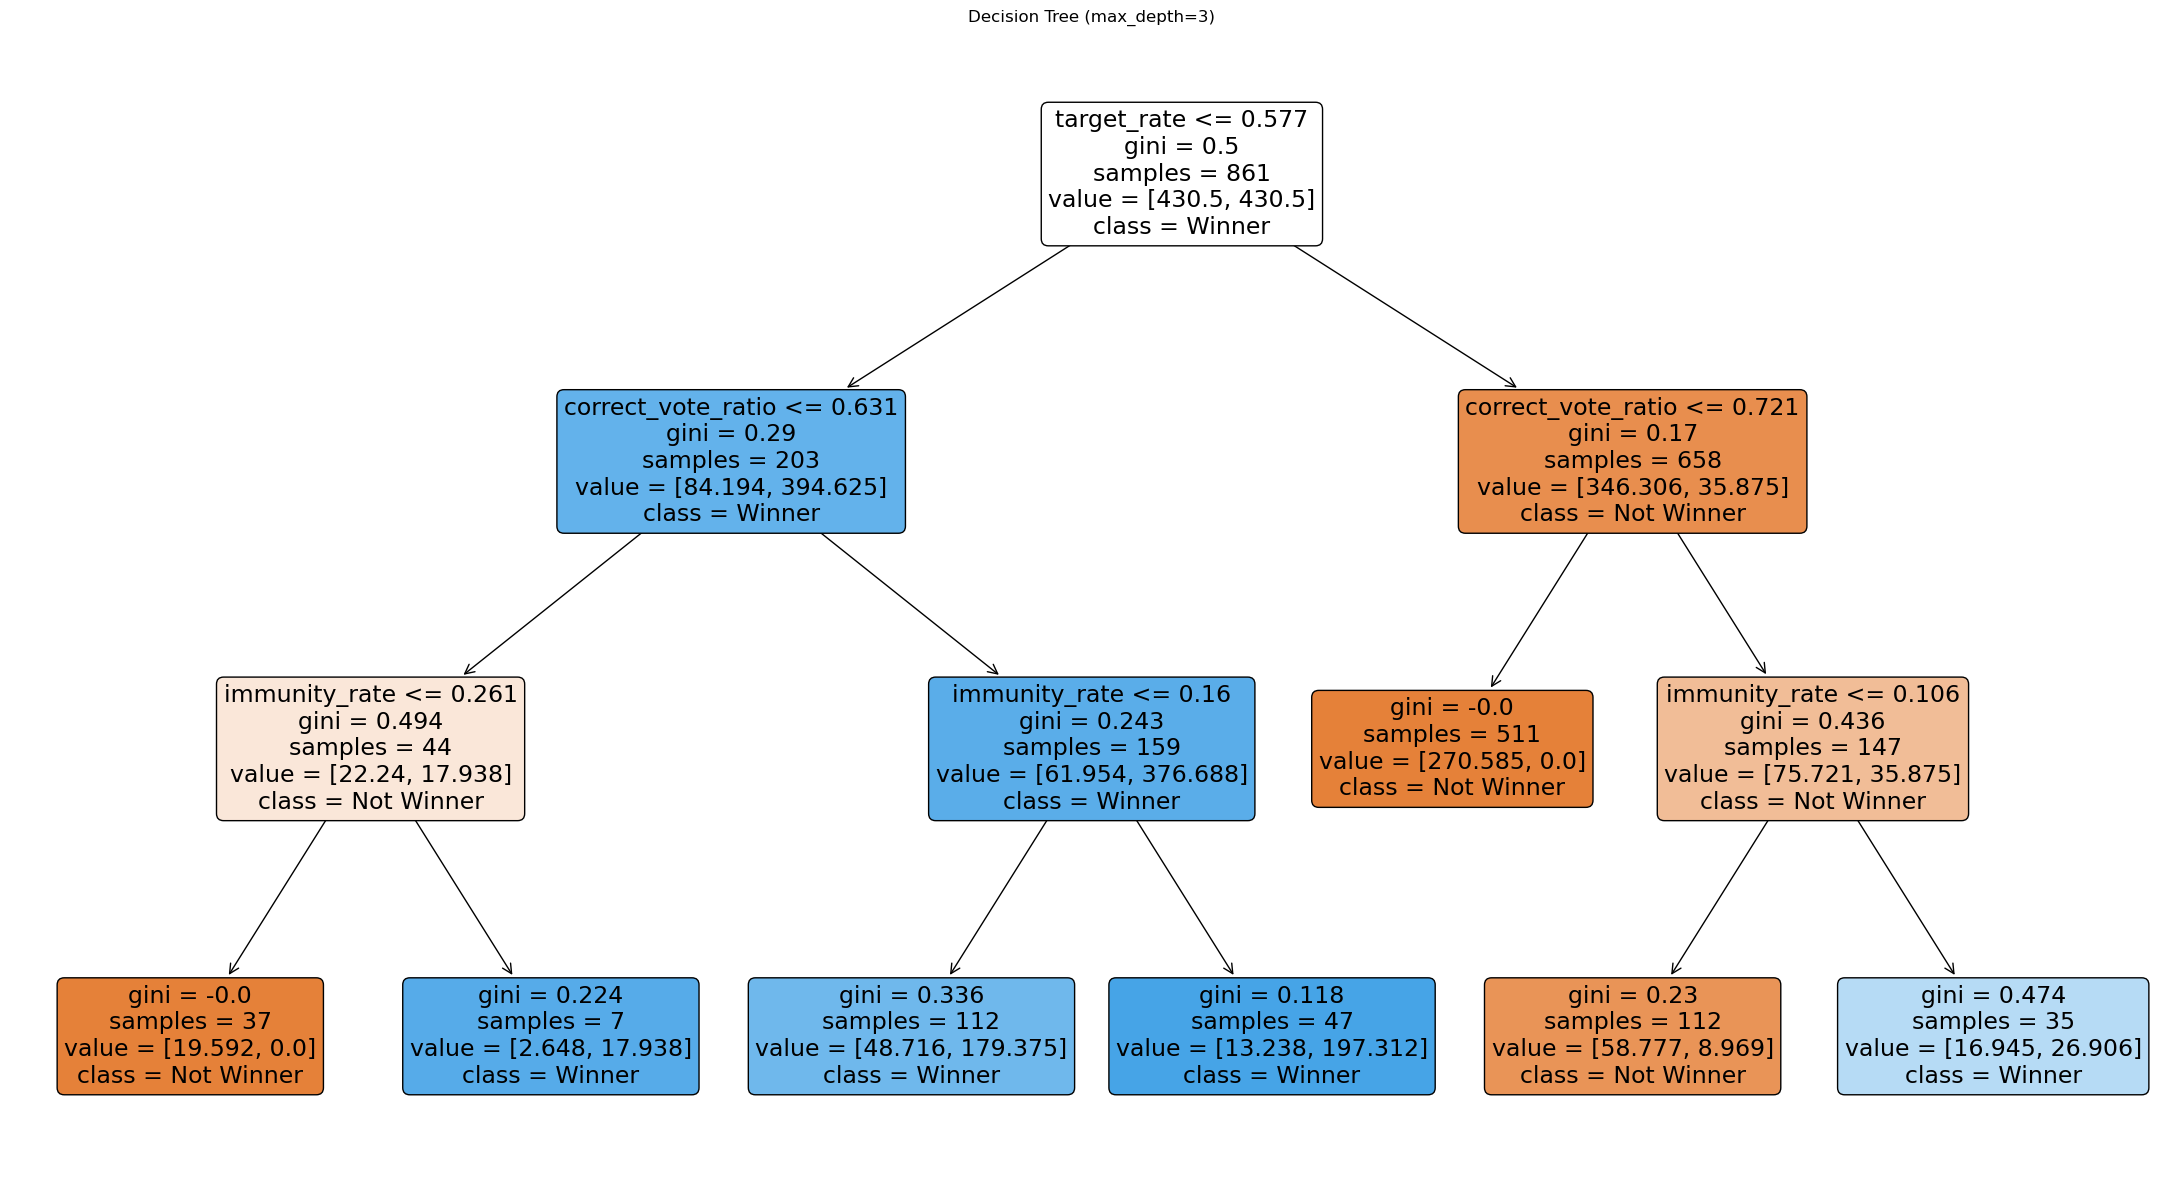

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight="balanced")
dt.fit(X, y)

dt_scores = cross_val_score(dt, X, y, cv=5, scoring="roc_auc")
print("Decision Tree — 5-fold CV ROC-AUC")
print(f"  Mean: {dt_scores.mean():.3f}  |  Std: {dt_scores.std():.3f}")

print("\nFeature importances:")
for feat, imp in zip(features, dt.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

plt.figure(figsize=(22, 12))
plot_tree(dt, feature_names=features, class_names=["Not Winner", "Winner"],
          filled=True, rounded=True, fontsize=17)
plt.title("Decision Tree (max_depth=3)")
plt.tight_layout()
plt.show()

In [ ]:
season_to_num = {
    "Borneo": 1, "Australian Outback": 2, "Africa": 3, "Marquesas": 4,
    "Thailand": 5, "The Amazon": 6, "Pearl Islands": 7, "All-Stars": 8,
    "Vanuatu": 9, "Palau": 10, "Guatemala": 11, "Panama": 12,
    "Cook Islands": 13, "Fiji": 14, "China": 15, "Micronesia": 16,
    "Gabon": 17, "Tocantins": 18, "Samoa": 19,
    "Heroes vs. Villains": 20, "Nicaragua": 20,
    "Redemption Island": 21, "South Pacific": 22, "Philippines": 23,
    "One World": 24, "Caramoan": 24, "Blood vs. Water": 25, "Cagayan": 26,
    "San Juan del Sur": 27, "Worlds Apart": 28, "Cambodia": 29,
    "Kaôh Rōng": 30, "Millenials vs. Gen X": 31, "Millennials vs. Gen X": 31,
    "Game Changers": 32, "Heroes vs. Healers vs. Hustlers": 33,
    "Ghost Island": 34, "David vs. Goliath": 35, "Edge of Extinction": 36,
    "Island of the Idols": 37, "Winners at War": 38,
    "Survivor 41": 41, "Survivor 42": 42, "Survivor 43": 43,
    "Survivor 44": 44, "Survivor 45": 45, "Survivor 46": 46,
    "Survivor 47": 47, "Survivor 48": 48,
}

era_map = {
    "Old School (1-10)": range(1, 11),
    "Middle School (11-20)": range(11, 21),
    "Dark Era (21-27)": range(21, 28),
    "Advantages Era (28-38)": range(28, 39),
    "New Era (41+)": range(41, 49),
}

def get_era(season_name):
    num = season_to_num.get(season_name)
    if num is None:
        return "Unknown"
    for era, seasons in era_map.items():
        if num in seasons:
            return era
    return "Unknown"

df_strategy["season_num"] = df_strategy["seasonplayed"].map(season_to_num)
df_strategy["era"] = df_strategy["seasonplayed"].apply(get_era)

print("Still unknown:", df_strategy[df_strategy["era"] == "Unknown"]["seasonplayed"].unique())
print(df_strategy["era"].value_counts())

Still unknown: []
era
Advantages Era (28-38)    212
Middle School (11-20)     203
Old School (1-10)         168
Dark Era (21-27)          148
New Era (41+)             144
Name: count, dtype: int64


In [ ]:
winner_by_era = df_strategy[df_strategy["is_winner"] == 1].groupby("era")[[
    "target_rate", "correct_vote_ratio", "immunity_rate", "threat_score"
]].mean().round(3)

era_order = list(era_map.keys())
winner_by_era = winner_by_era.reindex(era_order)

print("Average winner stats by era:")
print(winner_by_era)

Average winner stats by era:
                        target_rate  correct_vote_ratio  immunity_rate  \
era                                                                      
Old School (1-10)             0.190               0.912          0.194   
Middle School (11-20)         0.360               0.849          0.121   
Dark Era (21-27)              0.292               0.859          0.194   
Advantages Era (28-38)        0.456               0.765          0.170   
New Era (41+)                 0.240               0.811          0.177   

                        threat_score  
era                                   
Old School (1-10)              0.238  
Middle School (11-20)          0.244  
Dark Era (21-27)               0.269  
Advantages Era (28-38)         0.250  
New Era (41+)                  0.233  


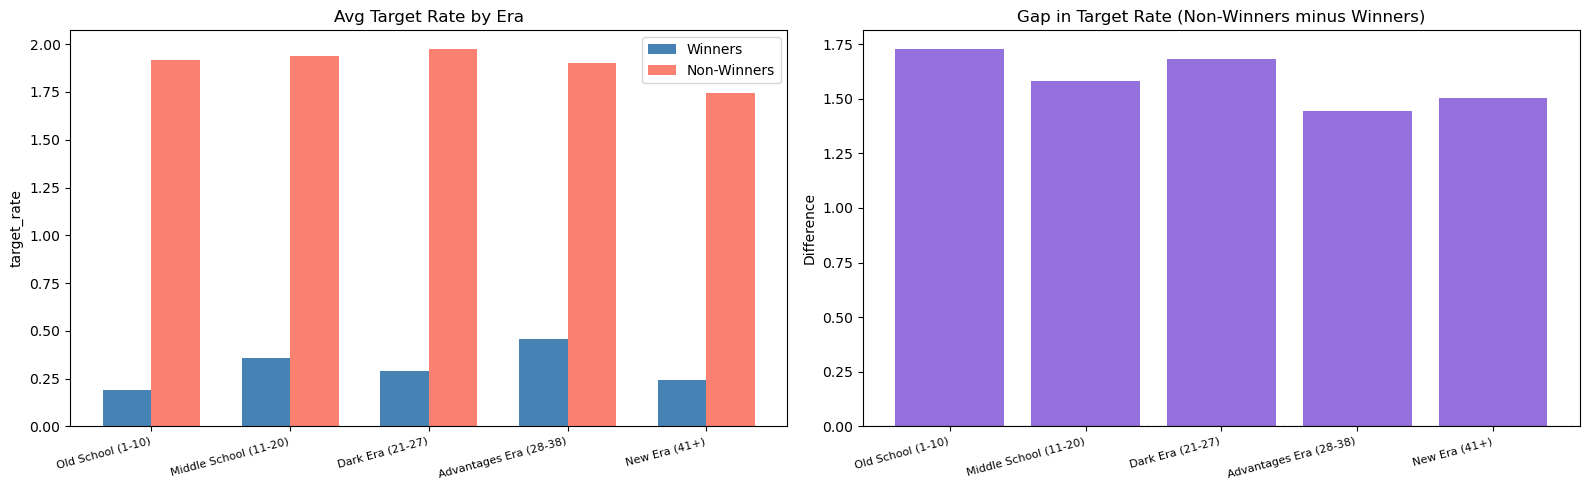

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: target_rate by era (winners vs non-winners) ---
winner_era = df_strategy[df_strategy["is_winner"] == 1].groupby("era")["target_rate"].mean()
loser_era = df_strategy[df_strategy["is_winner"] == 0].groupby("era")["target_rate"].mean()

winner_era = winner_era.reindex(era_order)
loser_era = loser_era.reindex(era_order)

x = np.arange(len(era_order))
width = 0.35

axes[0].bar(x - width/2, winner_era.values, width, label="Winners", color="steelblue")
axes[0].bar(x + width/2, loser_era.values, width, label="Non-Winners", color="salmon")
axes[0].set_xticks(x)
axes[0].set_xticklabels(era_order, rotation=15, ha="right", fontsize=8)
axes[0].set_title("Avg Target Rate by Era")
axes[0].set_ylabel("target_rate")
axes[0].legend()

# --- Plot 2: gap between non-winner and winner target_rate ---
gap = loser_era.values - winner_era.values
axes[1].bar(era_order, gap, color="mediumpurple")
axes[1].set_xticks(range(len(era_order)))
axes[1].set_xticklabels(era_order, rotation=15, ha="right", fontsize=8)
axes[1].set_title("Gap in Target Rate (Non-Winners minus Winners)")
axes[1].set_ylabel("Difference")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")


plt.tight_layout()
plt.show()

In [ ]:
import warnings
warnings.filterwarnings("ignore")

features = [
    "correct_vote_ratio", "immunity_rate",
    "target_rate", "threat_score"
]
era_order = [
    "Old School (1-10)", "Middle School (11-20)", "Dark Era (21-27)",
    "Advantages Era (28-38)", "New Era (41+)"
]

print(f"{'Era':<25} {'AUC':>6}  {'correct_vote':>13} {'immunity':>9} "
      f"{'target':>8} {'threat':>8}")
print("-" * 75)

era_coefs = {}

for era in era_order:
    subset = df_strategy_clean_ir[df_strategy_clean_ir["era"] == era]
    X = subset[features]
    y = subset["is_winner"]

    if y.sum() < 3:
        print(f"{era:<25}  insufficient winners")
        continue

    scaler_era = StandardScaler()
    X_scaled = scaler_era.fit_transform(X)

    lr_era = LogisticRegression(max_iter=1000, class_weight="balanced")
    scores = cross_val_score(lr_era, X_scaled, y, cv=5, scoring="roc_auc")
    lr_era.fit(X_scaled, y)

    coefs = dict(zip(features, lr_era.coef_[0]))
    era_coefs[era] = coefs

    print(f"{era:<25} {scores.mean():>6.3f}  "
          f"{coefs['correct_vote_ratio']:>13.3f} "
          f"{coefs['immunity_rate']:>9.3f} "
          f"{coefs['target_rate']:>8.3f} "
          f"{coefs['threat_score']:>8.3f}")

Era                          AUC   correct_vote  immunity   target   threat
---------------------------------------------------------------------------
Old School (1-10)          0.929          2.207     0.648   -2.914    0.011
Middle School (11-20)      0.856          1.201     0.435   -3.058    0.418
Dark Era (21-27)           0.952          2.280     0.722   -2.321    0.230
Advantages Era (28-38)     0.847          0.769     0.596   -2.706    0.357
New Era (41+)              0.899          1.026     0.515   -3.157    0.323


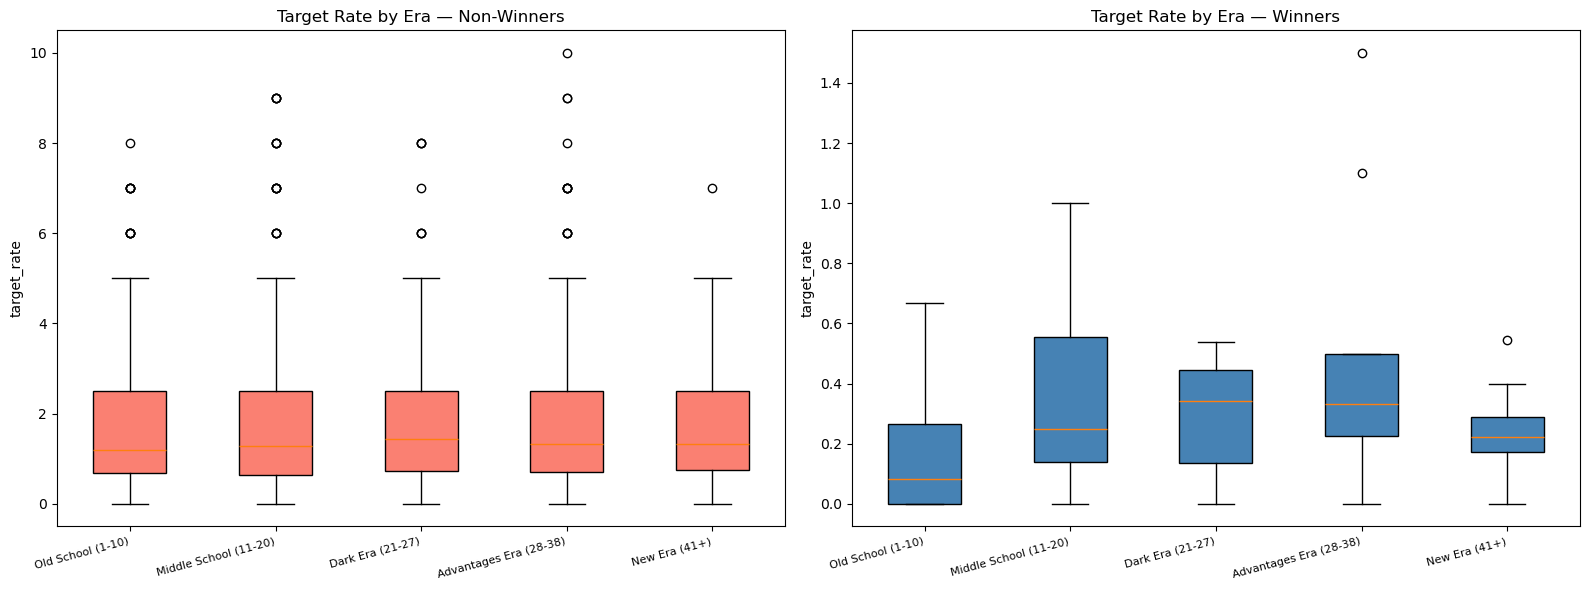

In [ ]:
import matplotlib.pyplot as plt

era_order = ["Old School (1-10)", "Middle School (11-20)", "Dark Era (21-27)",
             "Advantages Era (28-38)", "New Era (41+)"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, is_win in zip(axes, ["Non-Winners", "Winners"], [0, 1]):
    data = [
        df_strategy_clean_ir[
            (df_strategy_clean_ir["era"] == era) &
            (df_strategy_clean_ir["is_winner"] == is_win)
        ]["target_rate"].values
        for era in era_order
    ]
    bp = ax.boxplot(data, patch_artist=True, labels=era_order)

    color = "salmon" if is_win == 0 else "steelblue"
    for patch in bp["boxes"]:
        patch.set_facecolor(color)

    ax.set_title(f"Target Rate by Era — {label}")
    ax.set_ylabel("target_rate")
    ax.set_xticklabels(era_order, rotation=15, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

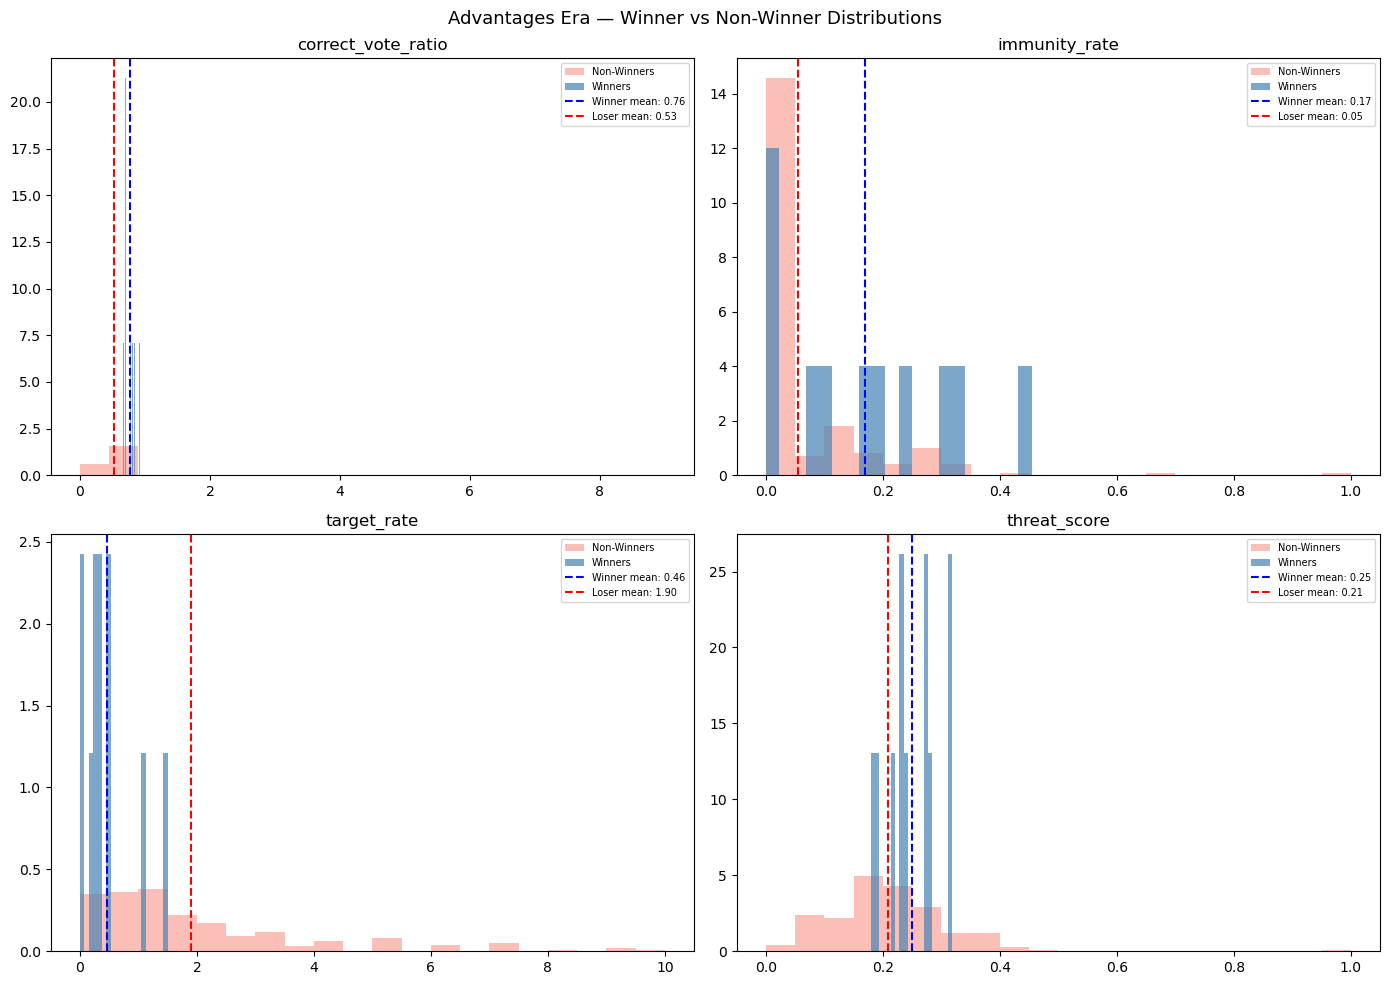

Advantages Era — Winner stat thresholds:
       correct_vote_ratio  immunity_rate  target_rate  threat_score
count              11.000         11.000       11.000        11.000
mean                0.765          0.170        0.456         0.250
std                 0.079          0.152        0.457         0.047
min                 0.667          0.000        0.000         0.180
25%                 0.692          0.042        0.225         0.225
50%                 0.769          0.167        0.333         0.241
75%                 0.809          0.269        0.500         0.277
max                 0.923          0.455        1.500         0.319


In [ ]:
advantages_era = df_strategy[df_strategy["era"] == "Advantages Era (28-38)"]
winners = advantages_era[advantages_era["is_winner"] == 1]
losers = advantages_era[advantages_era["is_winner"] == 0]

import matplotlib.pyplot as plt
import pandas as pd

features = ["correct_vote_ratio", "immunity_rate", "target_rate", "threat_score"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), features):
    ax.hist(losers[feat], bins=20, alpha=0.5, label="Non-Winners", color="salmon", density=True)
    ax.hist(winners[feat], bins=20, alpha=0.7, label="Winners", color="steelblue", density=True)
    ax.axvline(winners[feat].mean(), color="blue", linestyle="--", label=f"Winner mean: {winners[feat].mean():.2f}")
    ax.axvline(losers[feat].mean(), color="red", linestyle="--", label=f"Loser mean: {losers[feat].mean():.2f}")
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.suptitle("Advantages Era — Winner vs Non-Winner Distributions", fontsize=13)
plt.tight_layout()
plt.show()

# Percentile thresholds for the simulator
print("Advantages Era — Winner stat thresholds:")
print(winners[features].describe(percentiles=[0.25, 0.5, 0.75]).round(3))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")

features_adv = [
    "correct_vote_ratio",
    "immunity_rate",
    "target_rate",
    "threat_score",
    "timesswapped",
    "negation_rate",
]

adv_era = df_strategy_clean_ir[
    (df_strategy_clean_ir["era"] == "Advantages Era (28-38)") &
    (df_strategy_clean_ir["made_merge"] == 1)
].copy()

X = adv_era[features_adv]
y = adv_era["is_winner"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
scores = cross_val_score(lr, X_scaled, y, cv=5, scoring="roc_auc")
lr.fit(X_scaled, y)

print(f"Advantages Era (merge players, clean) — AUC: {scores.mean():.3f} ± {scores.std():.3f}\n")
print("Feature coefficients (sorted by importance):")
for feat, coef in sorted(zip(features_adv, lr.coef_[0]),
                         key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:<25} {coef:>+.3f}")

Advantages Era (merge players, clean) — AUC: 0.884 ± 0.072

Feature coefficients (sorted by importance):
  correct_vote_ratio        +1.890
  target_rate               -1.765
  immunity_rate             +0.932
  negation_rate             +0.911
  threat_score              -0.542
  timesswapped              -0.125
